In [3]:
# ============================================================
# Artifact-Aware Context CNN + Transformer — v3 (MTC Added)
#
# v2 থেকে নতুন:
#   ✅ Multi-Task Classifier (MTC):
#      - Main:  5-class sleep staging
#      - Aux 1: N1 vs non-N1 (binary)
#      - Aux 2: N3 vs non-N3 (binary)
#      - Aux 3: Wake vs Sleep (binary)
#      একসাথে ৪টা task → N1/N3 F1 বাড়ে
#
# v2 থেকে যা আছে:
#   1. Focal Loss (gamma=1.0)
#   2. SpectralFeatureExtractor
#   3. Data Augmentation (N1/N3)
#   4. Gentle N1 weight boost
#   5. CE clamp + weight clip
#
# Purpose (কেন এই কোড):
#   EEG সিগনাল থেকে ঘুমের stage (Wake/N1/N2/N3/REM) classify করা।
#   Wearanize+ wearable device থেকে পাওয়া EEG data তে artifact
#   (noise, missing data) থাকে। সেই artifact কে weight দিয়ে
#   training এ কম গুরুত্ব দেওয়া হয় যাতে model clean data থেকে
#   বেশি শেখে। N1 stage সবচেয়ে কঠিন classify করতে — তাই
#   Focal Loss + Spectral features + Augmentation দিয়ে N1 কে
#   বিশেষ গুরুত্ব দেওয়া হয়েছে।
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS & CONFIG
# ============================================================
SAVE_PATH     = r"D:\22\AA\preprocess\preprocessed_FFinal"
ARTIFACT_PATH = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"
EVAL_PATH     = r"D:\22\AA\evaluation\artifact-aware_ContextCnnTransformerF_MTC"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 3
WINDOW      = 2 * CONTEXT + 1
N_EPOCHS    = 50
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]
FS          = 100   # Wearanize+ sampling rate (Hz) — প্রয়োজনে পরিবর্তন করুন

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Seeds  : {SEEDS}")
print(f"Output : {EVAL_PATH}")

# ============================================================
# ARTIFACT WEIGHT CONFIG
# TSV score → loss weight mapping
# 0 = clean      → 1.0 (পুরো loss নাও)
# 1 = no data    → 0.0 (ignore, gradient নেই)
# 2 = high noise → 0.4 (40% loss)
# 3 = spiky      → 0.2 (20% loss)
# 4 = M-shaped   → 0.1 (10% loss)
# ============================================================
ARTIFACT_WEIGHT_MAP = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}

TARGET_CHANNELS   = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_CHANNELS = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]


# ============================================================
# ARTIFACT WEIGHT LOADER (আগের মতোই)
# ============================================================
def load_artifact_weights(subject_id, artifact_path, epoch_duration=30):
    tsv_path = os.path.join(
        artifact_path, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return None

    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return None

    available = [ch for ch in TARGET_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_CHANNELS if ch in df.columns]
    if not available:
        return None

    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // epoch_duration).astype(int)

    epoch_scores = df.groupby('sleep_epoch')['worst_score'].max()
    n_epochs     = int(epoch_scores.index.max()) + 1
    weights      = np.ones(n_epochs, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        weights[int(ep_idx)] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)

    return weights


# ============================================================
# SUBJECT SPLIT — FIXED (seed=42)
# ============================================================
all_subjects = sorted([
    f.replace(".npz", "")
    for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])

_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

if os.path.exists(_train_path) and os.path.exists(_test_path):
    TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
    TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
    print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")
else:
    _subs = all_subjects.copy()
    random.seed(42)
    random.shuffle(_subs)
    n          = int(0.8 * len(_subs))
    TRAIN_SUBS = _subs[:n]
    TEST_SUBS  = _subs[n:]
    np.save(_train_path, np.array(TRAIN_SUBS))
    np.save(_test_path,  np.array(TEST_SUBS))
    print(f"Split created -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print(f"TEST_SUBS: {TEST_SUBS}")


# ============================================================
# ✅ NEW: DATA AUGMENTATION HELPER
# N1 এবং N3 class এর জন্য synthetic perturbation
# পেপার: "subtle perturbations for N1, stronger for N3"
# ============================================================
def augment_epoch(x, label):
    """
    x     : numpy array (WINDOW, C, T)
    label : int (0~4)
    return: augmented x (same shape)
    """
    if label not in [1, 3]:   # শুধু N1(1) এবং N3(3)
        return x

    x = x.copy()
    aug_type = random.randint(0, 2)

    if aug_type == 0:
        # Gaussian noise — N1: subtle (σ=0.05), N3: moderate (σ=0.08)
        sigma = 0.05 if label == 1 else 0.08
        x = x + np.random.normal(0, sigma, x.shape).astype(np.float32)

    elif aug_type == 1:
        # Temporal shift ±250 samples (center epoch শুধু)
        shift = random.randint(-250, 250)
        x     = np.roll(x, shift, axis=-1)

    elif aug_type == 2:
        if label == 3:
            # Amplitude scaling শুধু N3 এর জন্য (0.8~1.2×)
            scale = random.uniform(0.8, 1.2)
            x     = x * scale
        else:
            # N1: slight DC offset removal (temporal normalization)
            x = x - x.mean(axis=-1, keepdims=True)

    return x.astype(np.float32)


# ============================================================
# DATASET — Artifact-Aware + Augmentation
# ============================================================
class ArtifactAwareDataset(Dataset):
    """
    প্রতিটা sample এ (x, y, weight) return করে।
    augment=True হলে N1/N3 class এ random perturbation।
    """
    def __init__(self, subject_list, data_path,
                 artifact_path, context=CONTEXT, augment=False):
        self.context = context
        self.augment = augment
        self.data    = []
        self.index   = []

        label_counter  = Counter()
        weight_counter = Counter()
        no_tsv_count   = 0

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue

            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],    :]
                signal = np.concatenate(
                    [eeg, eog], axis=1
                ).astype(np.float32)
                labels = d['labels'].copy()

            n = len(labels)

            art_w = load_artifact_weights(sub, artifact_path)
            if art_w is None:
                art_w        = np.ones(n, dtype=np.float32)
                no_tsv_count += 1
            else:
                if len(art_w) >= n:
                    art_w = art_w[:n]
                else:
                    pad   = np.ones(n - len(art_w), dtype=np.float32)
                    art_w = np.concatenate([art_w, pad])

            sub_idx = len(self.data)
            self.data.append((signal, labels))

            for i in range(n):
                w = float(art_w[i])
                self.index.append((sub_idx, i, n, w))
                label_counter[int(labels[i])] += 1
                weight_counter[round(w, 1)]   += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(5)],
            dtype=np.float32
        )

        total = len(self.index)
        ram   = sum(s.nbytes for s, _ in self.data) / 1e9
        print(f"  Samples  : {total:,}  (augment={augment})")
        print(f"  RAM      : {ram:.2f} GB")
        print(f"  No TSV   : {no_tsv_count} subjects")
        print(f"  Weight distribution:")
        for w in sorted(weight_counter.keys(), reverse=True):
            pct = weight_counter[w] / total * 100
            print(f"    w={w:.1f} : {weight_counter[w]:>7,} ({pct:.1f}%)")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])

        x = np.stack(window_epochs, axis=0)    # (WINDOW, 3, 3000)
        y = int(labels[center_i])

        # ✅ Augmentation (train only)
        if self.augment and y in [1, 3]:
            x = augment_epoch(x, y)

        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32)
        )


# Dataset build
print("\nBuilding datasets (once for all seeds)...")
train_ds = ArtifactAwareDataset(
    TRAIN_SUBS, SAVE_PATH, ARTIFACT_PATH, augment=True    # ✅ train: augment ON
)
print()
test_ds = ArtifactAwareDataset(
    TEST_SUBS, SAVE_PATH, ARTIFACT_PATH, augment=False    # ✅ test: augment OFF
)
print("Datasets ready.")


# ============================================================
# POSITIONAL ENCODING (আগের মতোই)
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


# ============================================================
# ✅ NEW: SPECTRAL FEATURE EXTRACTOR
#
# কেন দরকার:
#   CNN শুধু time-domain pattern দেখে। কিন্তু EEG sleep staging
#   এ frequency band গুলো সবচেয়ে গুরুত্বপূর্ণ:
#     - Delta (0.5-4 Hz)  → N3 deep sleep
#     - Theta (4-8 Hz)    → N1 (এটা N1 identify করার key)
#     - Alpha (8-13 Hz)   → Wake
#     - Sigma (12-16 Hz)  → N2 spindles
#     - Beta  (13-30 Hz)  → REM / Wake
#   FFT দিয়ে এই band গুলোর power আলাদাভাবে extract করে
#   model কে explicit frequency information দেওয়া হয়।
# ============================================================
class SpectralFeatureExtractor(nn.Module):
    def __init__(self, fs=100, n_out=32):
        super().__init__()
        self.fs = fs
        # 5 EEG bands: absolute power + relative power = 10 features
        self.bands = [
            (0.5, 4.0),   # Delta  → N3
            (4.0, 8.0),   # Theta  → N1
            (8.0, 13.0),  # Alpha  → Wake
            (12.0, 16.0), # Sigma  → N2 spindles
            (13.0, 30.0), # Beta   → REM/Wake
        ]
        self.mlp = nn.Sequential(
            nn.Linear(10, 64), nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_out), nn.GELU(),
        )

    def forward(self, x):
        """
        x: (B, WINDOW, C, T)
        center epoch এর channel-0 (EEG) থেকে spectral features বের করে।
        return: (B, n_out)
        """
        B, W, C, T = x.shape
        center = x[:, W // 2, 0, :]         # (B, T) — center epoch, EEG ch0

        # FFT magnitude spectrum
        fft_mag = torch.abs(
            torch.fft.rfft(center, dim=-1)
        )                                    # (B, T//2+1)
        freqs = torch.fft.rfftfreq(
            T, d=1.0 / self.fs
        ).to(x.device)                       # (T//2+1,)

        band_powers = []
        for lo, hi in self.bands:
            mask = (freqs >= lo) & (freqs < hi)
            if mask.sum() == 0:
                # band টা এই fs তে নেই — zero দাও
                bp = torch.zeros(B, 1, device=x.device)
            else:
                bp = fft_mag[:, mask].mean(dim=-1, keepdim=True)
            band_powers.append(bp)

        abs_power = torch.cat(band_powers, dim=-1)         # (B, 5)
        total     = abs_power.sum(dim=-1, keepdim=True) + 1e-8
        rel_power = abs_power / total                       # (B, 5) relative

        feats = torch.cat([abs_power, rel_power], dim=-1)  # (B, 10)
        return self.mlp(feats)                              # (B, n_out)


# ============================================================
# ✅ v3 MODEL — Context CNN + Transformer + Spectral + MTC
#
# Multi-Task Classifier (MTC) কীভাবে কাজ করে:
#   fused feature (160 dim) থেকে ৪টা classifier একসাথে চলে:
#   1. main_cls  : 5-class (Wake/N1/N2/N3/REM)
#   2. n1_cls    : N1 vs non-N1 (binary) — theta wave focus
#   3. n3_cls    : N3 vs non-N3 (binary) — delta wave focus
#   4. wake_cls  : Wake vs Sleep (binary) — beta wave focus
#
#   Training এ: total_loss = main_loss + λ*(n1_loss + n3_loss + wake_loss)
#   Inference এ: শুধু main_cls output ব্যবহার হয়
# ============================================================
class ContextCNNTransformerMTC(nn.Module):
    def __init__(
        self, in_ch=3, d_model=128, nhead=8,
        num_layers=3, dim_ff=256, dropout=0.4,
        n_classes=5, context=CONTEXT,
        spectral_out=32, fs=100, aux_lambda=0.25
    ):
        super().__init__()
        self.context     = context
        self.d_model     = d_model
        self.aux_lambda  = aux_lambda

        # ── Epoch-level CNN ──────────────────────────────────
        self.epoch_cnn = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=50, stride=6, padding=25),
            nn.BatchNorm1d(32), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(32, 64, kernel_size=8, padding=4),
            nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            intra_seq = self.epoch_cnn(
                torch.zeros(1, in_ch, 3000)
            ).shape[2]

        # ── Intra-epoch Transformer ──────────────────────────
        self.intra_pos = PositionalEncoding(
            d_model, max_len=intra_seq + 10, dropout=dropout
        )
        self.intra_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=1
        )

        # ── Inter-epoch Transformer ──────────────────────────
        self.inter_pos = PositionalEncoding(
            d_model, max_len=WINDOW + 2, dropout=dropout
        )
        self.inter_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=num_layers
        )

        # ── Spectral Branch ───────────────────────────────────
        self.spectral = SpectralFeatureExtractor(fs=fs, n_out=spectral_out)

        fused_dim = d_model + spectral_out   # 160

        # ── Main Classifier (5-class) ─────────────────────────
        self.main_cls = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, 128), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64), nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, n_classes),
        )

        # ── Aux Classifiers (binary, attention-enhanced) ──────
        # পেপারের মতো: attention gate দিয়ে task-specific feature enhance
        # N1: theta band (4-8 Hz) focus
        # N3: delta band (0.5-4 Hz) focus
        # Wake: beta band (13-30 Hz) focus
        def make_aux_head(in_dim):
            return nn.Sequential(
                nn.Linear(in_dim, 64), nn.GELU(),
                nn.Dropout(dropout * 0.5),
                nn.Linear(64, 2),   # binary: class vs non-class
            )

        def make_attn_gate(in_dim):
            return nn.Sequential(
                nn.Linear(in_dim, in_dim), nn.GELU(),
                nn.Linear(in_dim, in_dim), nn.Sigmoid(),
            )

        self.n1_gate   = make_attn_gate(fused_dim)
        self.n3_gate   = make_attn_gate(fused_dim)
        self.wake_gate = make_attn_gate(fused_dim)

        self.n1_cls   = make_aux_head(fused_dim)
        self.n3_cls   = make_aux_head(fused_dim)
        self.wake_cls = make_aux_head(fused_dim)

    def forward(self, x):
        B, W, C, T = x.shape

        # CNN → intra Transformer
        feat = self.epoch_cnn(x.view(B * W, C, T)).permute(0, 2, 1)
        feat = self.intra_transformer(
            self.intra_pos(feat)
        ).mean(dim=1).view(B, W, self.d_model)

        # Inter-epoch Transformer
        feat        = self.inter_transformer(self.inter_pos(feat))
        center_feat = feat[:, self.context, :]   # (B, d_model)

        # Spectral features
        spec_feat = self.spectral(x)             # (B, spectral_out)

        # Fused representation
        fused = torch.cat([center_feat, spec_feat], dim=-1)  # (B, 160)

        # Main 5-class output
        main_out = self.main_cls(fused)          # (B, 5)

        # Aux outputs (attention-gated)
        n1_out   = self.n1_cls(fused * self.n1_gate(fused))
        n3_out   = self.n3_cls(fused * self.n3_gate(fused))
        wake_out = self.wake_cls(fused * self.wake_gate(fused))

        return main_out, n1_out, n3_out, wake_out


# ============================================================
# ✅ NEW: FOCAL LOSS
#
# কেন দরকার:
#   Normal CrossEntropy সব sample কে সমান গুরুত্ব দেয়।
#   কিন্তু N1 মাত্র ~5-10% data — model সহজেই N2/Wake
#   predict করে accuracy বাড়ায়, N1 ignore করে।
#   Focal Loss: সহজ sample (pt বড়) এর loss কমায়,
#   কঠিন sample (pt ছোট, N1 এর মতো) এর loss বাড়ায়।
#   Formula: FL = -(1-pt)^gamma * log(pt)
#   gamma=2.5 → N1/N3 এ বেশি focus
# ============================================================
class ArtifactFocalLoss(nn.Module):
    """
    Focal Loss + Artifact Weight একসাথে।
    clean epoch (w=1.0) → পুরো focal loss
    noisy epoch (w=0.4) → 40% focal loss
    no-data epoch (w=0.0) → loss=0, gradient নেই
    """
    def __init__(self, gamma=2.5, class_weight=None):
        super().__init__()
        self.gamma        = gamma
        self.class_weight = class_weight   # (n_classes,) tensor

    def forward(self, logits, labels, artifact_weights):
        # Per-sample cross-entropy (unreduced)
        ce = nn.CrossEntropyLoss(
            weight=self.class_weight, reduction='none'
        )(logits, labels)                   # (B,)

        # ✅ FIX: ce clamp — exploding loss ঠেকাতে
        ce = torch.clamp(ce, max=10.0)

        # Focal scaling: (1 - pt)^gamma
        pt    = torch.exp(-ce)
        focal = (1.0 - pt) ** self.gamma * ce   # (B,)

        # Artifact weighting
        weighted = focal * artifact_weights     # (B,)

        # weight=0 sample বাদ দিয়ে mean
        valid = artifact_weights > 0
        if valid.sum() == 0:
            return weighted.mean()
        return weighted[valid].mean()


# ============================================================
# CLASS WEIGHTS — train data + manual N1 boost (পেপারের মতো)
# ============================================================
cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)

# ✅ FIX: Manual boost অনেক কমানো হয়েছে
# আগে: [1.0, 2.0, 1.1, 1.5, 1.6] — অনেক বেশি ছিল
# এখন: [1.0, 1.3, 1.0, 1.2, 1.1] — gentle boost
MANUAL_BOOST = np.array([1.0, 1.3, 1.0, 1.2, 1.1], dtype=np.float32)

cw_np = cw_np * MANUAL_BOOST
# ✅ FIX: clip করো — কোনো weight যেন 4.0 এর বেশি না হয়
cw_np = np.clip(cw_np, 0.5, 4.0)
cw_np = cw_np / cw_np.mean()
cw    = torch.FloatTensor(cw_np).to(device)

print(f"\nClass weights (dynamic + gentle N1 boost):")
for name, w in zip(LABEL_NAMES, cw_np):
    print(f"  {name}: {w:.3f}")

# ✅ FIX: gamma 2.5 → 1.0 (শুরুতে stable training)
# gamma=2.5 অনেক aggressive — model প্রথম কয়েক epoch এ
# কিছুই শিখতে পারে না। gamma=1.0 দিয়ে শুরু করলে
# প্রথম থেকেই ঠিকমতো শেখে।
criterion = ArtifactFocalLoss(gamma=1.0, class_weight=cw)


# ============================================================
# HELPERS
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


# ============================================================
# TRAIN / EVAL FUNCTIONS
# ============================================================
def train_epoch_fn(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    preds, labs = [], []

    for i, (x, y, w) in enumerate(loader):
        x, y, w = x.to(device), y.to(device), w.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y, w)    # ✅ Focal Loss + artifact weight
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds.extend(out.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
        if (i + 1) % 300 == 0:
            print(f"  batch {i+1}/{len(loader)}", end="\r")

    acc = accuracy_score(labs, preds)
    f1  = f1_score(labs, preds, average='macro', zero_division=0)
    return total_loss / len(loader), acc, f1


def evaluate_fn(model, loader):
    model.eval()
    preds, labs, weights_all = [], [], []

    with torch.no_grad():
        for x, y, w in loader:
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
            weights_all.extend(w.numpy())

    preds       = np.array(preds)
    labs        = np.array(labs)
    weights_all = np.array(weights_all)

    acc     = accuracy_score(labs, preds)
    f1      = f1_score(labs, preds, average='macro', zero_division=0)
    kappa   = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None, zero_division=0)

    clean_mask = weights_all == 1.0
    noisy_mask = (weights_all > 0) & (weights_all < 1.0)

    clean_acc = accuracy_score(
        labs[clean_mask], preds[clean_mask]
    ) if clean_mask.sum() > 0 else 0.0
    noisy_acc = accuracy_score(
        labs[noisy_mask], preds[noisy_mask]
    ) if noisy_mask.sum() > 0 else 0.0

    return (acc, f1, kappa, per_cls, preds, labs,
            clean_acc, noisy_acc,
            int(clean_mask.sum()), int(noisy_mask.sum()))


# ============================================================
# CSV LOG SETUP
# ============================================================
csv_epoch_path = os.path.join(EVAL_PATH, "all_seeds_epoch_log.csv")
with open(csv_epoch_path, 'w', newline='') as f:
    csv.writer(f).writerow([
        'seed', 'epoch',
        'tr_loss', 'tr_acc', 'tr_f1',
        'vl_acc', 'vl_f1', 'vl_kappa',
        'clean_acc', 'noisy_acc'
    ])

csv_summary_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa",
          "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
          "clean_acc", "noisy_acc"]
with open(csv_summary_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()


# ============================================================
# 5-SEED TRAINING LOOP
# ============================================================
all_seed_results = []
all_cms          = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"SEED {seed}  ({seed_idx + 1}/{len(SEEDS)})")
    print(f"{'='*60}")

    set_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0
    )

    # ✅ Improved model (Spectral branch সহ)
    model    = ContextCNNTransformerImproved(
        in_ch=3, fs=FS
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")

    optimizer = optim.AdamW(
        model.parameters(),
        lr=5e-4, weight_decay=3e-4,
        betas=(0.9, 0.98), eps=1e-9
    )
    total_steps  = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=warmup_cosine
    )

    best_f1   = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")
    history   = []

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_epoch_fn(
            model, train_loader, optimizer, scheduler
        )
        (vl_acc, vl_f1, vl_kap, vl_per,
         _, _, clean_acc, noisy_acc,
         n_clean, n_noisy) = evaluate_fn(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch': epoch,
            'tr_loss': tr_loss, 'tr_acc': tr_acc, 'tr_f1': tr_f1,
            'vl_acc': vl_acc,   'vl_f1': vl_f1,   'vl_kap': vl_kap,
            'clean_acc': clean_acc, 'noisy_acc': noisy_acc
        })

        print(
            f"  Ep[{epoch:02d}/{N_EPOCHS}] "
            f"Loss:{tr_loss:.3f} TrAcc:{tr_acc:.3f} "
            f"ValAcc:{vl_acc:.3f} F1:{vl_f1:.3f} "
            f"k:{vl_kap:.3f} LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("    Per-class F1: " + " | ".join(
                f"{LABEL_NAMES[i]}={vl_per[i]:.3f}" for i in range(5)
            ))
            print(f"    Clean:{clean_acc:.3f}({n_clean})  "
                  f"Noisy:{noisy_acc:.3f}({n_noisy})")

        with open(csv_epoch_path, 'a', newline='') as f:
            csv.writer(f).writerow([
                seed, epoch,
                f"{tr_loss:.4f}", f"{tr_acc:.4f}", f"{tr_f1:.4f}",
                f"{vl_acc:.4f}", f"{vl_f1:.4f}", f"{vl_kap:.4f}",
                f"{clean_acc:.4f}", f"{noisy_acc:.4f}"
            ])

    # Final eval with best checkpoint
    model.load_state_dict(torch.load(best_path, map_location=device))
    (fin_acc, fin_f1, fin_kap, fin_per,
     fin_preds, fin_labels,
     fin_clean_acc, fin_noisy_acc,
     fin_n_clean, fin_n_noisy) = evaluate_fn(model, test_loader)

    fin_cm = confusion_matrix(fin_labels, fin_preds)
    all_cms.append(fin_cm)

    print(f"\n  Seed {seed} FINAL:")
    print(f"  {'='*51}")
    print(f"  Accuracy      : {fin_acc*100:.2f}%")
    print(f"  Macro F1      : {fin_f1:.4f}")
    print(f"  Cohen Kappa   : {fin_kap:.4f}")
    print(f"  Clean Acc     : {fin_clean_acc*100:.2f}% ({fin_n_clean} epochs)")
    print(f"  Noisy Acc     : {fin_noisy_acc*100:.2f}% ({fin_n_noisy} epochs)")
    print(f"  {'-'*51}")
    print("  Per-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        bar = chr(9608) * int(fin_per[i] * 16)
        print(f"    {name:6s}: {fin_per[i]:.4f}  {bar}")
    print(f"  {'='*51}")

    result = {
        'seed':      seed,
        'acc':       fin_acc,
        'f1':        fin_f1,
        'kappa':     fin_kap,
        'per_cls':   fin_per,
        'clean_acc': fin_clean_acc,
        'noisy_acc': fin_noisy_acc,
        'n_clean':   fin_n_clean,
        'n_noisy':   fin_n_noisy,
        'preds':     fin_preds,
        'labels':    fin_labels,
        'history':   history,
    }
    all_seed_results.append(result)

    with open(csv_summary_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed":      seed,
            "acc":       round(fin_acc,  4),
            "f1_macro":  round(fin_f1,   4),
            "kappa":     round(fin_kap,  4),
            "f1_Wake":   round(fin_per[0], 4),
            "f1_N1":     round(fin_per[1], 4),
            "f1_N2":     round(fin_per[2], 4),
            "f1_N3":     round(fin_per[3], 4),
            "f1_REM":    round(fin_per[4], 4),
            "clean_acc": round(fin_clean_acc, 4),
            "noisy_acc": round(fin_noisy_acc, 4),
        })


# ============================================================
# FINAL REPORT — Mean ± Std
# ============================================================
print(f"\n{'='*60}")
print("5-SEED FINAL REPORT — IMPROVED MODEL")
print(f"{'='*60}")

accs   = np.array([r['acc']   for r in all_seed_results]) * 100
f1s    = np.array([r['f1']    for r in all_seed_results])
kappas = np.array([r['kappa'] for r in all_seed_results])
n1s    = np.array([r['per_cls'][1] for r in all_seed_results])
c_accs = np.array([r['clean_acc'] for r in all_seed_results]) * 100
n_accs = np.array([r['noisy_acc'] for r in all_seed_results]) * 100

print(f"\n{'Seed':<8} {'Acc%':>7} {'F1':>7} {'Kappa':>7} "
      f"{'N1':>7} {'CleanAcc':>10} {'NoisyAcc':>10}")
print("-" * 60)
for r in all_seed_results:
    print(f"{r['seed']:<8} "
          f"{r['acc']*100:>7.2f} "
          f"{r['f1']:>7.4f} "
          f"{r['kappa']:>7.4f} "
          f"{r['per_cls'][1]:>7.4f} "
          f"{r['clean_acc']*100:>10.2f} "
          f"{r['noisy_acc']*100:>10.2f}")
print("-" * 60)
print(f"{'Mean':<8} "
      f"{accs.mean():>7.2f} "
      f"{f1s.mean():>7.4f} "
      f"{kappas.mean():>7.4f} "
      f"{n1s.mean():>7.4f} "
      f"{c_accs.mean():>10.2f} "
      f"{n_accs.mean():>10.2f}")
print(f"{'Std':<8} "
      f"{accs.std():>7.2f} "
      f"{f1s.std():>7.4f} "
      f"{kappas.std():>7.4f} "
      f"{n1s.std():>7.4f} "
      f"{c_accs.std():>10.2f} "
      f"{n_accs.std():>10.2f}")

print(f"\nPaper format:")
print(f"  Accuracy : {accs.mean():.2f} ± {accs.std():.2f}%")
print(f"  Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"  Kappa    : {kappas.mean():.4f} ± {kappas.std():.4f}")
print(f"  N1 F1    : {n1s.mean():.4f} ± {n1s.std():.4f}")

print(f"\nPer-class F1 (mean ± std):")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r['per_cls'][i] for r in all_seed_results])
    print(f"  {name:6s}: {vals.mean():.4f} ± {vals.std():.4f}")

with open(csv_summary_path, 'a', newline='') as f:
    w = csv.DictWriter(f, fields)
    w.writerow({"seed": "mean",
                "acc":       round(accs.mean()/100, 4),
                "f1_macro":  round(f1s.mean(),    4),
                "kappa":     round(kappas.mean(),  4),
                "f1_Wake":   round(np.mean([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":     round(np.mean([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":     round(np.mean([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":     round(np.mean([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":    round(np.mean([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.mean()/100, 4),
                "noisy_acc": round(n_accs.mean()/100, 4)})
    w.writerow({"seed": "std",
                "acc":       round(accs.std()/100, 4),
                "f1_macro":  round(f1s.std(),    4),
                "kappa":     round(kappas.std(),  4),
                "f1_Wake":   round(np.std([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":     round(np.std([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":     round(np.std([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":     round(np.std([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":    round(np.std([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.std()/100, 4),
                "noisy_acc": round(n_accs.std()/100, 4)})

print(f"\nSummary saved: {csv_summary_path}")


# ============================================================
# PLOTS
# ============================================================
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple']

# 1. Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for r, c in zip(all_seed_results, colors):
    h   = r['history']
    eps = [x['epoch'] for x in h]
    axes[0].plot(eps, [x['vl_acc']    for x in h], color=c, lw=1.5, label=f"seed={r['seed']}")
    axes[1].plot(eps, [x['vl_f1']     for x in h], color=c, lw=1.5, label=f"seed={r['seed']}")
    axes[2].plot(eps, [x['clean_acc'] for x in h], color=c, lw=1.5, ls='-',  label=f"clean s={r['seed']}")
    axes[2].plot(eps, [x['noisy_acc'] for x in h], color=c, lw=1.0, ls='--', label=f"noisy s={r['seed']}")

for ax, title, ylabel in zip(
    axes,
    ["Val Accuracy", "Val Macro F1", "Clean vs Noisy Acc"],
    ["Accuracy", "Macro F1", "Accuracy"]
):
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel); ax.legend(fontsize=6)
    ax.grid(alpha=0.3)

fig.suptitle("Improved Artifact-Aware Context CNN+Transformer — 5 Seeds\n"
             "(Focal Loss + Spectral Branch + Augmentation)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "training_curves_5seeds.png"), dpi=150)
plt.show()

# 2. Confusion matrix (best seed)
best_r = max(all_seed_results, key=lambda r: r['f1'])
cm     = confusion_matrix(best_r['labels'], best_r['preds'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title(f"Count (best seed={best_r['seed']})")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title(f"% (best seed={best_r['seed']})")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
fig.suptitle("Improved Artifact-Aware Context Transformer — Best Seed",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_seed.png"), dpi=150)
plt.show()

# 3. Per-class F1 bar chart
per_means = np.array([[r['per_cls'][i] for r in all_seed_results] for i in range(5)]).mean(axis=1)
per_stds  = np.array([[r['per_cls'][i] for r in all_seed_results] for i in range(5)]).std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(np.arange(5), per_means, yerr=per_stds, capsize=5,
              color=colors, edgecolor='black', alpha=0.85)
ax.set_xticks(np.arange(5)); ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.15)
ax.set_title("Per-class F1 — Mean ± Std (5 Seeds)\n"
             "Improved: Focal Loss + Spectral + Augmentation",
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, per_means, per_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
            f"{m:.3f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "per_class_f1_5seed.png"), dpi=150)
plt.show()

# 4. Box plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (vals, title, color) in zip(axes, [
    (accs,      "Accuracy (%)",  '#4C72B0'),
    (f1s*100,   "Macro F1 (%)",  '#DD8452'),
    (kappas*100,"Kappa (%)",     '#55A868'),
]):
    ax.boxplot(vals, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7))
    ax.scatter([1]*len(vals), vals, color='black', zorder=5, s=40)
    ax.set_title(title); ax.set_xticks([]); ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(vals.min()-1, vals.max()+1)
    ax.text(1, vals.mean(), f" μ={vals.mean():.2f}", va='center', fontsize=9)

fig.suptitle("5-Seed Distribution — Improved Artifact-Aware Context Transformer",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "boxplot_5seeds.png"), dpi=150)
plt.show()

# ============================================================
print(f"\n{'='*60}")
print(f"All outputs saved: {EVAL_PATH}")
print(f"  best_seed<N>.pt              (best model weights)")
print(f"  all_seeds_epoch_log.csv      (epoch-by-epoch log)")
print(f"  summary.csv                  (final results)")
print(f"  training_curves_5seeds.png")
print(f"  confusion_matrix_best_seed.png")
print(f"  per_class_f1_5seed.png")
print(f"  boxplot_5seeds.png")
print(f"{'='*60}")
print("Done!")

Device : cuda
Seeds  : [42, 123, 256, 789, 999]
Output : D:\22\AA\evaluation\artifact-aware_ContextCnnTransformerF_MTC
Split loaded -> Train:76  Test:20
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Building datasets (once for all seeds)...
  Samples  : 71,347  (augment=True)
  RAM      : 2.57 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  59,303 (83.1%)
    w=0.4 :     930 (1.3%)
    w=0.2 :   7,686 (10.8%)
    w=0.1 :   3,385 (4.7%)
    w=0.0 :      43 (0.1%)

  Samples  : 19,763  (augment=False)
  RAM      : 0.71 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  15,258 (77.2%)
    w=0.4 :     428 (2.2%)
    w=0.2 :   3,306 (16.7%)
    w=0.1 :     771 (3.9%)
Datasets ready.

Class weights (dynamic + gentle N1 boost):
  Wake: 1.048
  N1: 2.275
  N2: 0.284
  N3: 0.694
  REM

KeyboardInterrupt: 

Device : cuda
Seeds  : [42, 123, 256, 789, 999]
Output : D:\22\AA\evaluation\MSCNN_Artifact_Context_Transformer
Split loaded -> Train:76  Test:20
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Building datasets...
  Samples  : 71,347
  RAM      : 2.57 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  59,303 (83.1%)
    w=0.4 :     930 (1.3%)
    w=0.2 :   7,686 (10.8%)
    w=0.1 :   3,385 (4.7%)
    w=0.0 :      43 (0.1%)

  Samples  : 19,763
  RAM      : 0.71 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  15,258 (77.2%)
    w=0.4 :     428 (2.2%)
    w=0.2 :   3,306 (16.7%)
    w=0.1 :     771 (3.9%)
Datasets ready.

Class weights:
  Wake: 1.844
  N1: 3.142
  N2: 0.442
  N3: 1.016
  REM: 1.117

SEED 42  (1/5)
  Parameters: 596,197
  Ep[01/30] Loss:0.544 TrAcc:0.491 ValAcc:0

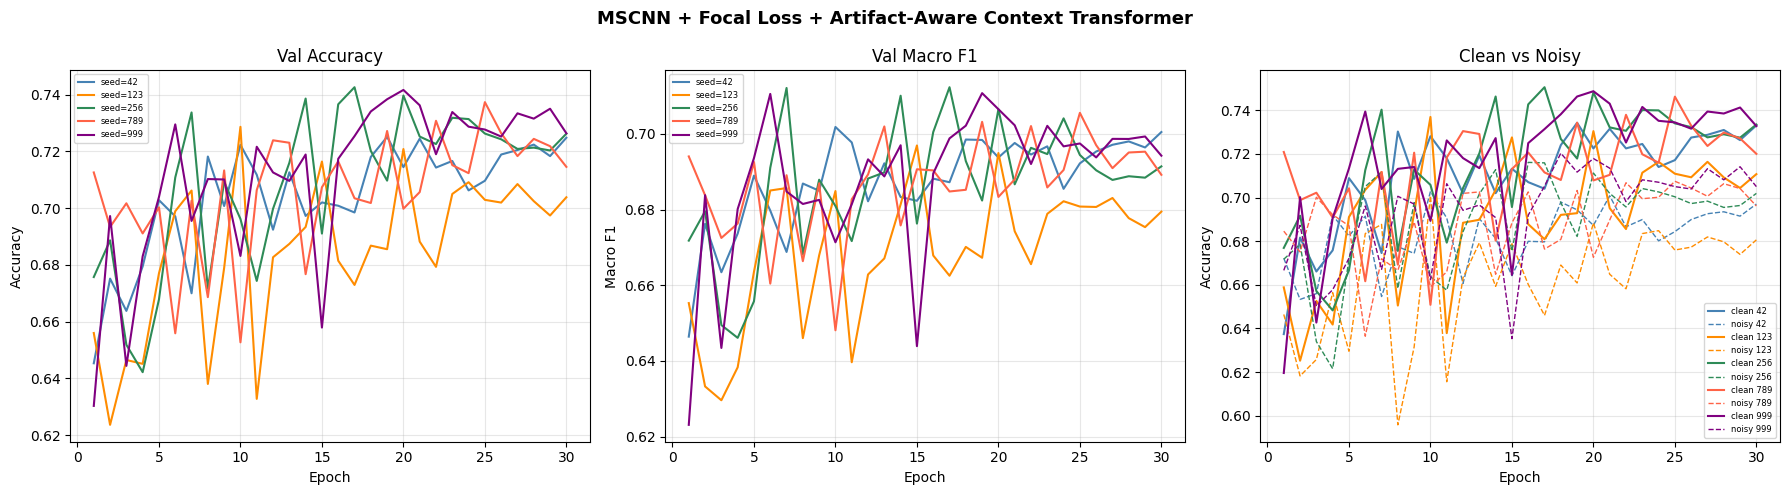

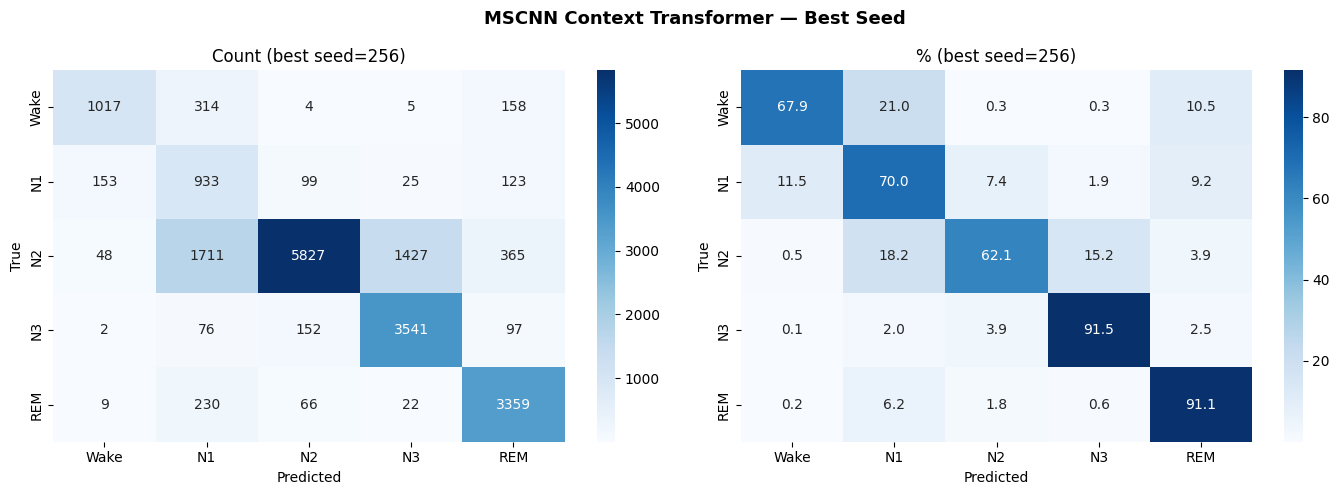

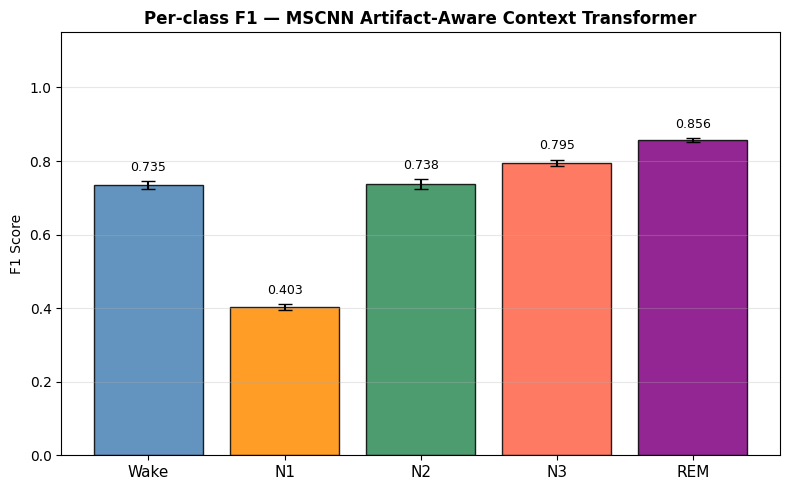

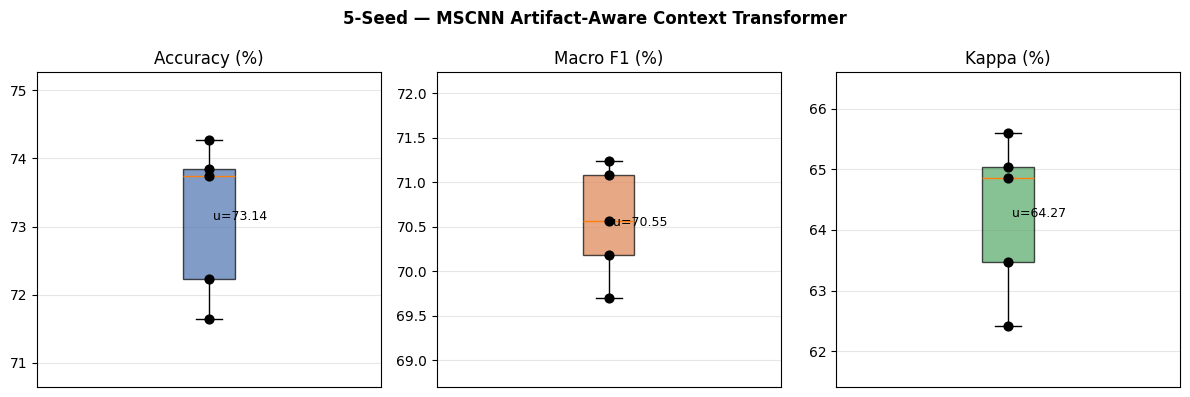


Saved: D:\22\AA\evaluation\MSCNN_Artifact_Context_Transformer
Done!


In [6]:
# ============================================================
# Multi-Scale Artifact-Aware Context CNN + Transformer
#
# Changes from single-scale version:
#   1. MSCNN: 4 kernel sizes (25,50,100,200) → concat
#      k=25  → spindles/sigma (12-16 Hz)
#      k=50  → theta (4-8 Hz) ← N1 important
#      k=100 → delta (0.5-4 Hz) ← N3 important
#      k=200 → slow oscillations
#   2. Focal Loss (gamma=2.0) → N1/N3 boost
#   3. Artifact-aware weighted loss (same as before)
#   4. Context window ±3 (same)
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS & CONFIG
# ============================================================
SAVE_PATH     = r"D:\22\AA\preprocess\preprocessed_FFinal"
ARTIFACT_PATH = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"
EVAL_PATH     = r"D:\22\AA\evaluation\MSCNN_Artifact_Context_Transformer"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 3
WINDOW      = 2 * CONTEXT + 1
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Seeds  : {SEEDS}")
print(f"Output : {EVAL_PATH}")

# ============================================================
# ARTIFACT CONFIG
# ============================================================
ARTIFACT_WEIGHT_MAP = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_CHANNELS     = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_CHANNELS   = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]


def load_artifact_weights(subject_id, artifact_path, epoch_duration=30):
    tsv_path = os.path.join(
        artifact_path, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return None
    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return None

    available = [ch for ch in TARGET_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_CHANNELS if ch in df.columns]
    if not available:
        return None

    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // epoch_duration).astype(int)
    epoch_scores      = df.groupby('sleep_epoch')['worst_score'].max()

    n_epochs = int(epoch_scores.index.max()) + 1
    weights  = np.ones(n_epochs, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        weights[int(ep_idx)] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)
    return weights


# ============================================================
# FIXED SPLIT
# ============================================================
all_subjects = sorted([
    f.replace(".npz", "")
    for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])

_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

if os.path.exists(_train_path) and os.path.exists(_test_path):
    TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
    TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
    print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")
else:
    _subs = all_subjects.copy()
    random.seed(42)
    random.shuffle(_subs)
    n          = int(0.8 * len(_subs))
    TRAIN_SUBS = _subs[:n]
    TEST_SUBS  = _subs[n:]
    np.save(_train_path, np.array(TRAIN_SUBS))
    np.save(_test_path,  np.array(TEST_SUBS))
    print(f"Split created -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print(f"TEST_SUBS: {TEST_SUBS}")


# ============================================================
# DATASET
# ============================================================
class ArtifactAwareDataset(Dataset):
    def __init__(self, subject_list, data_path,
                 artifact_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []

        label_counter  = Counter()
        weight_counter = Counter()
        no_tsv_count   = 0

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue

            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],    :]
                signal = np.concatenate(
                    [eeg, eog], axis=1
                ).astype(np.float32)
                labels = d['labels'].copy()

            n     = len(labels)
            art_w = load_artifact_weights(sub, artifact_path)

            if art_w is None:
                art_w        = np.ones(n, dtype=np.float32)
                no_tsv_count += 1
            else:
                if len(art_w) >= n:
                    art_w = art_w[:n]
                else:
                    art_w = np.concatenate(
                        [art_w, np.ones(n - len(art_w), dtype=np.float32)]
                    )

            sub_idx = len(self.data)
            self.data.append((signal, labels))

            for i in range(n):
                w = float(art_w[i])
                self.index.append((sub_idx, i, n, w))
                label_counter[int(labels[i])] += 1
                weight_counter[round(w, 1)]   += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(5)], dtype=np.float32
        )

        total = len(self.index)
        ram   = sum(s.nbytes for s, _ in self.data) / 1e9
        print(f"  Samples  : {total:,}")
        print(f"  RAM      : {ram:.2f} GB")
        print(f"  No TSV   : {no_tsv_count} subjects")
        print(f"  Weight distribution:")
        for w in sorted(weight_counter.keys(), reverse=True):
            pct = weight_counter[w] / total * 100
            print(f"    w={w:.1f} : {weight_counter[w]:>7,} ({pct:.1f}%)")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])

        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])

        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32)
        )


print("\nBuilding datasets...")
train_ds = ArtifactAwareDataset(TRAIN_SUBS, SAVE_PATH, ARTIFACT_PATH)
print()
test_ds  = ArtifactAwareDataset(TEST_SUBS,  SAVE_PATH, ARTIFACT_PATH)
print("Datasets ready.")


# ============================================================
# POSITIONAL ENCODING
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


# ============================================================
# MULTI-SCALE CNN MODULE
#
# 4 parallel branches, different kernel sizes:
#   k=25  → high freq (spindles, sigma 12-16Hz)
#   k=50  → theta (4-8Hz) ← N1 key
#   k=100 → delta (0.5-4Hz) ← N3 key
#   k=200 → slow oscillations
#
# Each branch: Conv → BN → GELU → MaxPool
# Output: concat along channel dim → projection to d_model
# ============================================================
class MSCNNBranch(nn.Module):
    """Single scale branch."""
    def __init__(self, in_ch, out_ch, kernel_size, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                      stride=max(1, kernel_size // 6),
                      padding=kernel_size // 2),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.MaxPool1d(4, 4),
        )

    def forward(self, x):
        return self.conv(x)    # (B, out_ch, L)


class MSCNN(nn.Module):
    """
    Multi-Scale CNN: 4 parallel branches → adaptive pool → concat → project.
    Output shape: (B, d_model, fixed_len)
    """
    def __init__(self, in_ch=3, branch_ch=32, d_model=128,
                 dropout=0.4, fixed_len=20):
        super().__init__()
        self.fixed_len = fixed_len

        # 4 branches with different kernel sizes
        self.branch_25  = MSCNNBranch(in_ch, branch_ch, 25,  dropout)
        self.branch_50  = MSCNNBranch(in_ch, branch_ch, 50,  dropout)
        self.branch_100 = MSCNNBranch(in_ch, branch_ch, 100, dropout)
        self.branch_200 = MSCNNBranch(in_ch, branch_ch, 200, dropout)

        # Residual: depthwise conv on original signal
        self.residual = nn.Sequential(
            nn.Conv1d(in_ch, branch_ch, kernel_size=1),
            nn.BatchNorm1d(branch_ch), nn.GELU(),
            nn.AdaptiveAvgPool1d(fixed_len)
        )

        # After concat: 4*branch_ch + branch_ch = 5*branch_ch → d_model
        concat_ch = 4 * branch_ch + branch_ch
        self.proj = nn.Sequential(
            nn.Conv1d(concat_ch, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: (B, in_ch, T)

        # Multi-scale branches → adaptive pool to fixed_len
        f25  = F.adaptive_avg_pool1d(self.branch_25(x),  self.fixed_len)
        f50  = F.adaptive_avg_pool1d(self.branch_50(x),  self.fixed_len)
        f100 = F.adaptive_avg_pool1d(self.branch_100(x), self.fixed_len)
        f200 = F.adaptive_avg_pool1d(self.branch_200(x), self.fixed_len)

        # Residual
        fres = self.residual(x)    # (B, branch_ch, fixed_len)

        # Concat all branches
        f_cat = torch.cat([f25, f50, f100, f200, fres], dim=1)

        # Project to d_model
        return self.proj(f_cat)    # (B, d_model, fixed_len)


# ============================================================
# FULL MODEL: MSCNN + Context Transformer
# ============================================================
class MSContextTransformer(nn.Module):
    def __init__(
        self,
        in_ch      = 3,
        branch_ch  = 32,
        d_model    = 128,
        nhead      = 8,
        num_layers = 3,
        dim_ff     = 256,
        dropout    = 0.4,
        n_classes  = 5,
        context    = CONTEXT,
        fixed_len  = 20,
    ):
        super().__init__()
        self.context  = context
        self.d_model  = d_model

        # Multi-Scale CNN backbone
        self.mscnn = MSCNN(
            in_ch=in_ch, branch_ch=branch_ch,
            d_model=d_model, dropout=dropout,
            fixed_len=fixed_len
        )

        # Intra-epoch Transformer (1 layer)
        self.intra_pos = PositionalEncoding(
            d_model, max_len=fixed_len + 10, dropout=dropout
        )
        self.intra_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=1
        )

        # Inter-epoch Transformer (num_layers)
        self.inter_pos = PositionalEncoding(
            d_model, max_len=WINDOW + 2, dropout=dropout
        )
        self.inter_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=num_layers
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: (B, WINDOW, in_ch, T)
        B, W, C, T = x.shape

        # Flatten window
        x_2d = x.view(B * W, C, T)       # (B*W, 3, 3000)

        # Multi-Scale CNN
        feat = self.mscnn(x_2d)           # (B*W, d_model, fixed_len)
        feat = feat.permute(0, 2, 1)      # (B*W, fixed_len, d_model)

        # Intra-epoch Transformer
        feat = self.intra_pos(feat)
        feat = self.intra_transformer(feat)
        feat = feat.mean(dim=1)           # (B*W, d_model)

        # Reshape to window
        feat = feat.view(B, W, self.d_model)

        # Inter-epoch Transformer
        feat = self.inter_pos(feat)
        feat = self.inter_transformer(feat)

        # Center epoch
        center = feat[:, self.context, :]
        return self.classifier(center)


# ============================================================
# FOCAL LOSS + ARTIFACT WEIGHTING
# ============================================================
class FocalLoss(nn.Module):
    """
    Focal Loss: FL = -alpha * (1-p)^gamma * log(p)
    gamma=2.0 → minority class 에 더 focus
    """
    def __init__(self, class_weights, gamma=2.0, reduction='none'):
        super().__init__()
        self.class_weights = class_weights
        self.gamma         = gamma
        self.reduction     = reduction

    def forward(self, logits, labels):
        ce_loss = F.cross_entropy(
            logits, labels,
            weight=self.class_weights,
            reduction='none'
        )
        pt      = torch.exp(-ce_loss)
        fl      = (1 - pt) ** self.gamma * ce_loss
        return fl   # (batch,)


def artifact_focal_loss(logits, labels, weights, focal_fn):
    """Focal loss + artifact weighting."""
    fl       = focal_fn(logits, labels)   # (batch,)
    weighted = fl * weights               # (batch,)
    valid    = weights > 0
    if valid.sum() == 0:
        return weighted.mean()
    return weighted[valid].mean()


# ============================================================
# CLASS WEIGHTS & FOCAL LOSS SETUP
# ============================================================
cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)
cw    = torch.FloatTensor(cw_np).to(device)
print(f"\nClass weights:")
for name, w in zip(LABEL_NAMES, cw_np):
    print(f"  {name}: {w:.3f}")


# ============================================================
# HELPERS
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def train_epoch_fn(model, loader, optimizer, scheduler, focal_fn):
    model.train()
    total_loss = 0
    preds, labs = [], []

    for i, (x, y, w) in enumerate(loader):
        x, y, w = x.to(device), y.to(device), w.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = artifact_focal_loss(out, y, w, focal_fn)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds.extend(out.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
        if (i + 1) % 300 == 0:
            print(f"  batch {i+1}/{len(loader)}", end="\r")

    acc = accuracy_score(labs, preds)
    f1  = f1_score(labs, preds, average='macro', zero_division=0)
    return total_loss / len(loader), acc, f1


def evaluate_fn(model, loader):
    model.eval()
    preds, labs, weights_all = [], [], []

    with torch.no_grad():
        for x, y, w in loader:
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
            weights_all.extend(w.numpy())

    preds       = np.array(preds)
    labs        = np.array(labs)
    weights_all = np.array(weights_all)

    acc     = accuracy_score(labs, preds)
    f1      = f1_score(labs, preds, average='macro',    zero_division=0)
    kappa   = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None,       zero_division=0)

    clean_mask = weights_all == 1.0
    noisy_mask = (weights_all > 0) & (weights_all < 1.0)
    clean_acc  = accuracy_score(labs[clean_mask], preds[clean_mask]) \
                 if clean_mask.sum() > 0 else 0.0
    noisy_acc  = accuracy_score(labs[noisy_mask], preds[noisy_mask]) \
                 if noisy_mask.sum() > 0 else 0.0

    return (acc, f1, kappa, per_cls, preds, labs,
            clean_acc, noisy_acc,
            int(clean_mask.sum()), int(noisy_mask.sum()))


# ============================================================
# CSV SETUP
# ============================================================
csv_epoch_path = os.path.join(EVAL_PATH, "all_seeds_epoch_log.csv")
with open(csv_epoch_path, 'w', newline='') as f:
    csv.writer(f).writerow([
        'seed', 'epoch', 'tr_loss', 'tr_acc', 'tr_f1',
        'vl_acc', 'vl_f1', 'vl_kappa', 'clean_acc', 'noisy_acc'
    ])

csv_summary_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa",
          "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
          "clean_acc", "noisy_acc"]
with open(csv_summary_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()


# ============================================================
# 5-SEED TRAINING LOOP
# ============================================================
all_seed_results = []
all_cms          = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"SEED {seed}  ({seed_idx + 1}/{len(SEEDS)})")
    print(f"{'='*60}")

    set_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0
    )

    model    = MSContextTransformer(in_ch=3).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")

    # Focal Loss
    focal_fn = FocalLoss(class_weights=cw, gamma=2.0)

    optimizer    = optim.AdamW(
        model.parameters(),
        lr=5e-4, weight_decay=3e-4,
        betas=(0.9, 0.98), eps=1e-9
    )
    total_steps  = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=warmup_cosine
    )

    best_f1   = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")
    history   = []

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_epoch_fn(
            model, train_loader, optimizer, scheduler, focal_fn
        )
        (vl_acc, vl_f1, vl_kap, vl_per,
         _, _, clean_acc, noisy_acc,
         n_clean, n_noisy) = evaluate_fn(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch': epoch,
            'tr_loss': tr_loss, 'tr_acc': tr_acc, 'tr_f1': tr_f1,
            'vl_acc': vl_acc,   'vl_f1': vl_f1,   'vl_kap': vl_kap,
            'clean_acc': clean_acc, 'noisy_acc': noisy_acc
        })

        print(
            f"  Ep[{epoch:02d}/{N_EPOCHS}] "
            f"Loss:{tr_loss:.3f} TrAcc:{tr_acc:.3f} "
            f"ValAcc:{vl_acc:.3f} F1:{vl_f1:.3f} "
            f"k:{vl_kap:.3f} LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("    Per-class F1: " + " | ".join(
                f"{LABEL_NAMES[i]}={vl_per[i]:.3f}" for i in range(5)
            ))
            print(f"    Clean:{clean_acc:.3f}({n_clean})  "
                  f"Noisy:{noisy_acc:.3f}({n_noisy})")

        with open(csv_epoch_path, 'a', newline='') as f:
            csv.writer(f).writerow([
                seed, epoch,
                f"{tr_loss:.4f}", f"{tr_acc:.4f}", f"{tr_f1:.4f}",
                f"{vl_acc:.4f}", f"{vl_f1:.4f}", f"{vl_kap:.4f}",
                f"{clean_acc:.4f}", f"{noisy_acc:.4f}"
            ])

    # Final eval
    model.load_state_dict(torch.load(best_path, map_location=device))
    (fin_acc, fin_f1, fin_kap, fin_per,
     fin_preds, fin_labels,
     fin_clean_acc, fin_noisy_acc,
     fin_n_clean, fin_n_noisy) = evaluate_fn(model, test_loader)

    fin_cm = confusion_matrix(fin_labels, fin_preds)
    all_cms.append(fin_cm)

    print(f"\n  Seed {seed} FINAL:")
    print(f"  {'='*51}")
    print(f"  Accuracy    : {fin_acc*100:.2f}%")
    print(f"  Macro F1    : {fin_f1:.4f}")
    print(f"  Kappa       : {fin_kap:.4f}")
    print(f"  Clean Acc   : {fin_clean_acc*100:.2f}% ({fin_n_clean})")
    print(f"  Noisy Acc   : {fin_noisy_acc*100:.2f}% ({fin_n_noisy})")
    print(f"  {'-'*51}")
    print("  Per-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        bar = chr(9608) * int(fin_per[i] * 16)
        print(f"    {name:6s}: {fin_per[i]:.4f}  {bar}")
    print(f"  {'='*51}")

    result = {
        'seed': seed, 'acc': fin_acc, 'f1': fin_f1, 'kappa': fin_kap,
        'per_cls': fin_per, 'clean_acc': fin_clean_acc,
        'noisy_acc': fin_noisy_acc, 'n_clean': fin_n_clean,
        'n_noisy': fin_n_noisy, 'preds': fin_preds,
        'labels': fin_labels, 'history': history,
    }
    all_seed_results.append(result)

    with open(csv_summary_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed": seed, "acc": round(fin_acc, 4),
            "f1_macro": round(fin_f1, 4), "kappa": round(fin_kap, 4),
            "f1_Wake": round(fin_per[0], 4), "f1_N1": round(fin_per[1], 4),
            "f1_N2":   round(fin_per[2], 4), "f1_N3": round(fin_per[3], 4),
            "f1_REM":  round(fin_per[4], 4),
            "clean_acc": round(fin_clean_acc, 4),
            "noisy_acc": round(fin_noisy_acc, 4),
        })


# ============================================================
# FINAL REPORT
# ============================================================
print(f"\n{'='*60}")
print("5-SEED FINAL REPORT — MSCNN Artifact-Aware Context Transformer")
print(f"{'='*60}")

accs   = np.array([r['acc']        for r in all_seed_results]) * 100
f1s    = np.array([r['f1']         for r in all_seed_results])
kappas = np.array([r['kappa']      for r in all_seed_results])
n1s    = np.array([r['per_cls'][1] for r in all_seed_results])
c_accs = np.array([r['clean_acc']  for r in all_seed_results]) * 100
n_accs = np.array([r['noisy_acc']  for r in all_seed_results]) * 100

print(f"\n{'Seed':<8} {'Acc%':>7} {'F1':>7} {'Kappa':>7} "
      f"{'N1':>7} {'CleanAcc':>10} {'NoisyAcc':>10}")
print("-" * 60)
for r in all_seed_results:
    print(f"{r['seed']:<8} {r['acc']*100:>7.2f} {r['f1']:>7.4f} "
          f"{r['kappa']:>7.4f} {r['per_cls'][1]:>7.4f} "
          f"{r['clean_acc']*100:>10.2f} {r['noisy_acc']*100:>10.2f}")
print("-" * 60)
print(f"{'Mean':<8} {accs.mean():>7.2f} {f1s.mean():>7.4f} "
      f"{kappas.mean():>7.4f} {n1s.mean():>7.4f} "
      f"{c_accs.mean():>10.2f} {n_accs.mean():>10.2f}")
print(f"{'Std':<8} {accs.std():>7.2f} {f1s.std():>7.4f} "
      f"{kappas.std():>7.4f} {n1s.std():>7.4f} "
      f"{c_accs.std():>10.2f} {n_accs.std():>10.2f}")

print(f"\nPaper format:")
print(f"  Accuracy : {accs.mean():.2f} +- {accs.std():.2f}%")
print(f"  Macro F1 : {f1s.mean():.4f} +- {f1s.std():.4f}")
print(f"  Kappa    : {kappas.mean():.4f} +- {kappas.std():.4f}")
print(f"  N1 F1    : {n1s.mean():.4f} +- {n1s.std():.4f}")

print(f"\nPer-class F1 (mean +- std):")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r['per_cls'][i] for r in all_seed_results])
    print(f"  {name:6s}: {vals.mean():.4f} +- {vals.std():.4f}")

# CSV
with open(csv_summary_path, 'a', newline='') as f:
    w = csv.DictWriter(f, fields)
    w.writerow({"seed": "mean", "acc": round(accs.mean()/100, 4),
                "f1_macro": round(f1s.mean(), 4), "kappa": round(kappas.mean(), 4),
                "f1_Wake": round(np.mean([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":   round(np.mean([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":   round(np.mean([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":   round(np.mean([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":  round(np.mean([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.mean()/100, 4),
                "noisy_acc": round(n_accs.mean()/100, 4)})
    w.writerow({"seed": "std", "acc": round(accs.std()/100, 4),
                "f1_macro": round(f1s.std(), 4), "kappa": round(kappas.std(), 4),
                "f1_Wake": round(np.std([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":   round(np.std([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":   round(np.std([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":   round(np.std([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":  round(np.std([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.std()/100, 4),
                "noisy_acc": round(n_accs.std()/100, 4)})

print(f"\nSummary saved: {csv_summary_path}")

# ============================================================
# PLOTS
# ============================================================
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for r, c in zip(all_seed_results, colors):
    h   = r['history']
    eps = [x['epoch'] for x in h]
    axes[0].plot(eps, [x['vl_acc']    for x in h], color=c, lw=1.5, label=f"seed={r['seed']}")
    axes[1].plot(eps, [x['vl_f1']     for x in h], color=c, lw=1.5, label=f"seed={r['seed']}")
    axes[2].plot(eps, [x['clean_acc'] for x in h], color=c, lw=1.5, ls='-',  label=f"clean {r['seed']}")
    axes[2].plot(eps, [x['noisy_acc'] for x in h], color=c, lw=1.0, ls='--', label=f"noisy {r['seed']}")

for ax, title, ylabel in zip(
    axes,
    ["Val Accuracy", "Val Macro F1", "Clean vs Noisy"],
    ["Accuracy", "Macro F1", "Accuracy"]
):
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel); ax.legend(fontsize=6); ax.grid(alpha=0.3)

fig.suptitle("MSCNN + Focal Loss + Artifact-Aware Context Transformer",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "training_curves_5seeds.png"), dpi=150)
plt.show()

best_r = max(all_seed_results, key=lambda r: r['f1'])
cm     = confusion_matrix(best_r['labels'], best_r['preds'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title(f"Count (best seed={best_r['seed']})")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title(f"% (best seed={best_r['seed']})")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
fig.suptitle("MSCNN Context Transformer — Best Seed", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_seed.png"), dpi=150)
plt.show()

per_means = np.array([[r['per_cls'][i] for r in all_seed_results] for i in range(5)]).mean(axis=1)
per_stds  = np.array([[r['per_cls'][i] for r in all_seed_results] for i in range(5)]).std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(np.arange(5), per_means, yerr=per_stds, capsize=5,
              color=colors, edgecolor='black', alpha=0.85)
ax.set_xticks(np.arange(5)); ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.15)
ax.set_title("Per-class F1 — MSCNN Artifact-Aware Context Transformer",
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, per_means, per_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
            f"{m:.3f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "per_class_f1_5seed.png"), dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (vals, title, color) in zip(axes, [
    (accs,      "Accuracy (%)",  '#4C72B0'),
    (f1s*100,   "Macro F1 (%)",  '#DD8452'),
    (kappas*100,"Kappa (%)",     '#55A868'),
]):
    ax.boxplot(vals, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7))
    ax.scatter([1]*len(vals), vals, color='black', zorder=5, s=40)
    ax.set_title(title); ax.set_xticks([]); ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(vals.min()-1, vals.max()+1)
    ax.text(1, vals.mean(), f" u={vals.mean():.2f}", va='center', fontsize=9)

fig.suptitle("5-Seed — MSCNN Artifact-Aware Context Transformer",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "boxplot_5seeds.png"), dpi=150)
plt.show()

print(f"\n{'='*60}")
print(f"Saved: {EVAL_PATH}")
print("Done!")